# ICT-26 — Convention de signalisation (expérience A, strate 7)

*Compagnon pédagogique du module `ict.signaling_convention` (#7746, jambe D2 expérience A).*

Cette expérience est la **ligne de base « sans coup ontologique »** de la strate 7 :
le vocabulaire est **FIXE** — aucun symbole n'est inventé (c'est l'expérience B,
*ICT-27-SymbolInvention*). On demande alors une chose précise et falsifiable :

> Partant de propensités **uniformes** (aucune signification pré-inscrite), un
> **code conventionnel** émerge-t-il spontanément par apprentissage par
> renforcement, et avec lui l'**information mutuelle** $I(\text{état} ; \text{signal})$
> qui mesure combien le signal en dit sur l'état ?

C'est le jeu de signalisation canonique de **David Lewis** (*Convention*, 1969) et
**Brian Skyrms** (*Signals*, 2010) : un émetteur observe l'état du monde et envoie
un signal ; un récepteur choisit une action ; le couple est récompensé quand
l'action correspond à l'état. Mécanisme d'apprentissage : **Roth-Erev** (softmax
avec température, annealing exploration→exploitation).

**Contraste avec B** : ici le vocabulaire est *donné* et bornant ; en B il est
*inventé* à la mesure du problème. Les deux notebooks se répondent : A montre ce
qu'un vocabulaire fixe **permet et borne**, B montre comment l'invention **lève**
la borne.

In [1]:
# Setup : import du package ict (via sys.path cwd, cf C973-L) + numpy/matplotlib.
import sys
sys.path.insert(0, ".")
import numpy as np
import matplotlib.pyplot as plt
from ict import signaling_convention as sc

publique = [n for n in dir(sc) if not n.startswith("_")]
print("ict.signaling_convention chargé.")
print("API publique :", publique)

ict.signaling_convention chargé.
API publique : ['Dict', 'Optional', 'Sequence', 'SignalingGame', 'Tuple', 'annotations', 'convention_stability_test', 'coordination_emerges_test', 'mi_tracks_meaning_test', 'mutual_information', 'np', 'vocabulary_bottleneck_test']


## 1. L'émergence sans signification pré-inscrite

Le verdict central : depuis des propensités **uniformes** (chaque signal aussi
bon qu'un autre au départ), un entraînement Roth-Erev fait-il émerger une
**convention** — c'est-à-dire un code où chaque état déclenche un signal
distinct, déclenchant à son tour la bonne action ?

On mesure deux quantités simultanément :

* le **taux de coordination** (succès : l'action correspond-elle à l'état ?) ;
* l'**information mutuelle** $I(\text{état} ; \text{signal})$, qui vaut $0$ si le
  signal n'informerait sur rien (*pooling* : un seul signal utilisé) et
  $\log_2(n_{\text{états}})$ si le signal code parfaitement l'état.

Un succès élevé **sans** information mutuelle serait suspect : ce serait une
coordination « par chance » ou par exploitation d'un biais, pas une convention
signifiante. Le verdict n'est satisfait que si les deux montent **ensemble** et
dominent nettement le contrôle sans-apprentissage.

Verdict coordination_emerges : emerged = True
  learned_success    = 1.000
  learned_mi         = 1.993
  control_success    = 0.241
  control_mi         = 0.004
  max_mi             = 2.000
  (contrôle = agents qui jouent leur politique uniforme SANS apprendre)


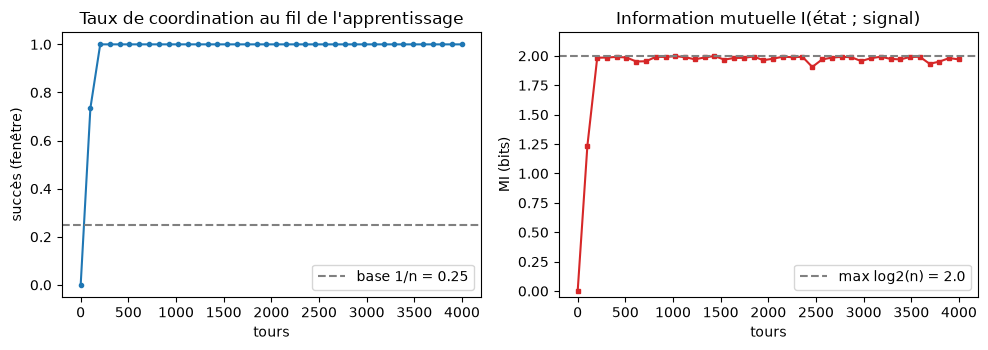

In [2]:
# Verdict EMERGENCE + trajectoire d'apprentissage instrumentée (n_states=4).
verdict = sc.coordination_emerges_test(n_states=4, n_signals=4, seed=0)
print("Verdict coordination_emerges : emerged =", bool(verdict["emerged"]))
for k in ("learned_success", "learned_mi", "control_success", "control_mi", "max_mi"):
    print(f"  {k:18} = {verdict[k]:.3f}")
print(f"  (contrôle = agents qui jouent leur politique uniforme SANS apprendre)")

# Trajectoire : succès glissant + information mutuelle glissante au fil des tours.
g = sc.SignalingGame(4, 4, temperature=0.6, rng=np.random.default_rng(0))
tours, succ, mi = sc._trajectory(g, 4000, anneal_to=0.15)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(tours, succ, "-o", ms=3, color="#1f77b4")
ax[0].axhline(0.25, ls="--", color="grey", label="base 1/n = 0.25")
ax[0].set_title("Taux de coordination au fil de l'apprentissage")
ax[0].set_xlabel("tours") ; ax[0].set_ylabel("succès (fenêtre)") ; ax[0].set_ylim(-0.05, 1.05)
ax[0].legend(loc="lower right")
ax[1].plot(tours, mi, "-s", ms=3, color="#d62728")
ax[1].axhline(np.log2(4), ls="--", color="grey", label="max log2(n) = 2.0")
ax[1].set_title("Information mutuelle I(état ; signal)")
ax[1].set_xlabel("tours") ; ax[1].set_ylabel("MI (bits)") ; ax[1].set_ylim(-0.05, 2.2)
ax[1].legend(loc="lower right")
fig.tight_layout() ; plt.show()

## 2. Le goulot de vocabulaire — ce que le FIXE borne

L'expérience A a un paramètre que B viendra exactement *déverrouiller* : la
**taille du vocabulaire** $n_{\text{signaux}}$. Avec $M < N$ signaux pour $N$
états, **aucun code** ne peut distinguer tous les états : c'est une borne de
**théorie de l'information**, pas une limite d'apprentissage. Le plafond de
signification est $\log_2(M)$.

On balaie $n_{\text{signaux}}$ de 1 à $N$ sous entraînement identique et on
observe le succès et la signification atteints. La courbe doit suivre le plafond
de codage — c'est précisément ce plafond que l'invention (expérience B) vient
pousser.

Verdict vocabulary_bottleneck : bottleneck = True
  mi_full_vocab          = 1.993
  mi_limited_vocab       = 0.506
  ratio_limited_over_full = 0.254


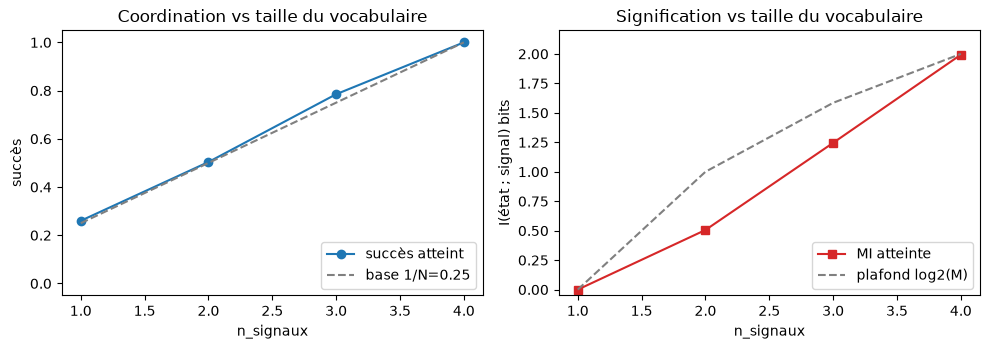

In [3]:
# Verdict GOULOT + balayage n_signals (n_states=4).
verdict = sc.vocabulary_bottleneck_test(n_states=4, seed=0)
print("Verdict vocabulary_bottleneck : bottleneck =", bool(verdict["bottleneck"]))
for k in ("mi_full_vocab", "mi_limited_vocab", "ratio_limited_over_full"):
    print(f"  {k:22} = {verdict[k]:.3f}")

# Balayage : succès + MI en fonction du nombre de signaux disponibles.
n_states = 4
nsigs = list(range(1, n_states + 1))
succ_sweep, mi_sweep = [], []
for nsig in nsigs:
    g = sc.SignalingGame(n_states, nsig, temperature=0.6, rng=np.random.default_rng(0))
    g.train(4000, anneal_to=0.15)
    g.joint_state_signal[:] = 0.0
    for _ in range(800):
        g.play_round(reinforce=False)
    succ_sweep.append(g.success_rate(800))
    mi_sweep.append(sc.mutual_information(g.joint_state_signal))
ceiling = [np.log2(max(n, 1)) for n in nsigs]

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(nsigs, succ_sweep, "-o", color="#1f77b4", label="succès atteint")
ax[0].plot(nsigs, [n / n_states for n in nsigs], "--", color="grey", label=f"base 1/N={1/n_states:.2f}")
ax[0].set_title("Coordination vs taille du vocabulaire") ; ax[0].set_xlabel("n_signaux")
ax[0].set_ylabel("succès") ; ax[0].set_ylim(-0.05, 1.05) ; ax[0].legend(loc="lower right")
ax[1].plot(nsigs, mi_sweep, "-s", color="#d62728", label="MI atteinte")
ax[1].plot(nsigs, ceiling, "--", color="grey", label="plafond log2(M)")
ax[1].set_title("Signification vs taille du vocabulaire") ; ax[1].set_xlabel("n_signaux")
ax[1].set_ylabel("I(état ; signal) bits") ; ax[1].set_ylim(-0.05, 2.2) ; ax[1].legend(loc="lower right")
fig.tight_layout() ; plt.show()

## 3. Succès ≠ signification — le contrôle à état dominant

Un taux de coordination élevé ne prouve pas qu'une convention *signifiante* s'est
formée. Le contrôle falsifiant : un jeu avec un **état dominant** (un état
représente 85 % des tirages). Les agents peuvent atteindre un succès élevé en
apprenant à **toujours choisir l'action de l'état dominant** — sans que le signal
ne porte la moindre information (MI faible).

Le verdict `mi_tracks_meaning` exige donc que succès et information mutuelle
**croissent ensemble** (corrélation forte sur la trajectoire), ET que le contrôle
à état dominant montre un succès comparable mais une MI nettement plus faible.
C'est ce qui distingue « réussir *via* signification » de « réussir *via*
exploitation d'un biais ».

In [4]:
# Verdict SENS : la MI suit-elle le succès ? Contrôle = état dominant.
verdict = sc.mi_tracks_meaning_test(n_states=4, seed=0)
print("Verdict mi_tracks_meaning : meaningful =", bool(verdict["meaningful"]))
for k in ("balanced_final_success", "balanced_final_mi", "balanced_corr_mi_success",
          "dominant_final_success", "dominant_final_mi"):
    print(f"  {k:26} = {verdict[k]:.3f}")
print()
print("Lecture : cas équilibré — succès ET MI élevés (signification) ;")
print("          cas dominant  — succès comparable MAIS MI faible (pas de signification).")

Verdict mi_tracks_meaning : meaningful = True
  balanced_final_success     = 1.000
  balanced_final_mi          = 1.970
  balanced_corr_mi_success   = 0.983
  dominant_final_success     = 0.961
  dominant_final_mi          = 0.855

Lecture : cas équilibré — succès ET MI élevés (signification) ;
          cas dominant  — succès comparable MAIS MI faible (pas de signification).


## 4. Stabilité de la convention — résistance aux chocs

Une convention établie est-elle **robuste** ? On entraîne une convention (succès
élevé), puis on perturbe les propensités en injectant du bruit additif **relatif**
à l'échelle des propensités elles-mêmes (en multiples de leur écart-type). Un
choc absolu serait négligeable : après des milliers de renforcements, les $Q$
atteignent des centaines.

* un choc **modéré** (≈ 0,5 écart-type) laisse la structure apprise dominante ;
* un choc **brutal** (≈ 6 écarts-types) l'oblitère.

Une convention stable résiste au choc modéré et se reconstruit vite par
ré-apprentissage ; le choc brutal l'effondre nettement plus.

In [5]:
# Verdict STABILITÉ : la convention résiste-t-elle aux perturbations ?
verdict = sc.convention_stability_test(n_states=4, seed=0)
print("Verdict convention_stability : stable =", bool(verdict["stable"]))
for k in ("established_success", "moderate_immediate", "moderate_recovered",
          "brutal_immediate", "brutal_recovered"):
    print(f"  {k:22} = {verdict[k]:.3f}")
print()
print("Lecture : choc modéré -> succès immédiat élevé (résiste), récupération rapide ;")
print("          choc brutal  -> succès immédiat effondré (la convention est détruite).")

Verdict convention_stability : stable = True
  established_success    = 1.000
  moderate_immediate     = 1.000
  moderate_recovered     = 1.000
  brutal_immediate       = 0.247
  brutal_recovered       = 0.242

Lecture : choc modéré -> succès immédiat élevé (résiste), récupération rapide ;
          choc brutal  -> succès immédiat effondré (la convention est détruite).


## Synthèse — la convention comme émergence du *meaning*

| Verdict | Ce qu'il montre | Contrôle falsifiant |
|---|---|---|
| **coordination_emerges** | Un code conventionnel émerge *sans* signification pré-inscrite | agents sans apprentissage (base $1/n$) |
| **vocabulary_bottleneck** | Un vocabulaire insuffisant borne strictement la signification | vocab. suffisant vs limité |
| **mi_tracks_meaning** | Succès et information mutuelle croissent *ensemble* | état dominant : succès sans signification |
| **convention_stability** | Une convention établie résiste aux chocs modérés | choc brutal qui l'effondre |

**Leçon de l'expérience A** : avec un vocabulaire **fixe**, la signification
émerge bien — mais elle est **bornée** par $\log_2(n_{\text{signaux}})$. C'est
exactement la borne que l'expérience B (*ICT-27-SymbolInvention*) lève en
laissant les agents **inventer** de nouveaux signaux à la mesure du problème.
Lewis (le *donné*) ouvre sur Skyrms (l'*inventé*).

## 5. Exercices

Trois exercices pour rendre la convention opératoire. Chaque stub s'exécute
**sans erreur** (C.1) — il affiche un résultat partiel ou une amorce. Complétez
le `TODO` pour répondre à la question.

In [6]:
# Exercice 1 — La température discrimine-t-elle une convergence robuste d'un piège de pooling ?
# TODO: pour chaque température, entraîner un SignalingGame(4,4) et noter le succès final.
#       Une température trop haute maintient-elle l'exploration (pooling) ? Une trop basse fige-t-elle trop tôt ?
temperatures = [0.1, 0.3, 0.6, 1.0, 1.5]
for T in temperatures:
    g = sc.SignalingGame(4, 4, temperature=T, rng=np.random.default_rng(0))
    g.train(3000, anneal_to=0.15)
    print(f"T={T:.1f} -> succès final = {g.success_rate(800):.3f}")

T=0.1 -> succès final = 1.000


T=0.3 -> succès final = 1.000
T=0.6 -> succès final = 1.000


T=1.0 -> succès final = 1.000
T=1.5 -> succès final = 1.000


### Exercice 2 — Réussir *sans* signifier (le contrôle à état dominant)

Reproduisez vous-même le contrôle de la §3 : avec un état fortement dominant,
les agents atteignent un succès élevé mais une information mutuelle faible.
Constatez l'écart entre « réussir » et « signifier ».

In [7]:
# Exercice 2 — stub (compléter)
# TODO: construire une distribution avec un état dominant (ex. 0.85), entraîner,
#       et comparer succès vs I(état ; signal). Vérifier : succès haut, MI basse.
n_states = 4
dom_dist = np.full(n_states, (1.0 - 0.85) / (n_states - 1))
dom_dist[0] = 0.85  # l'état 0 pèse 85 %
g = sc.SignalingGame(n_states, n_states, temperature=0.6, state_dist=dom_dist,
                     rng=np.random.default_rng(0))
g.train(3000, anneal_to=0.15)
g.joint_state_signal[:] = 0.0
for _ in range(800):
    g.play_round(reinforce=False)
print(f"succès = {g.success_rate(800):.3f}   MI = {sc.mutual_information(g.joint_state_signal):.3f}   (max log2(4)=2.0)")
print("-> succès élevé MAIS MI faible : on réussit SANS signifier.")

succès = 0.954   MI = 0.706   (max log2(4)=2.0)
-> succès élevé MAIS MI faible : on réussit SANS signifier.


### Exercice 3 — L'échelle de l'espace d'états

La convention émerge-t-elle aussi pour des espaces d'états plus grands ? Balaiez
$n_{\text{états}}$ et observez si le succès final reste élevé — et combien de
l'information mutuelle se rapproche du plafond $\log_2(n)$.

In [8]:
# Exercice 3 — stub (compléter)
# TODO: pour chaque n_states, entraîner et noter succès + MI, comparer à log2(n).
for n in [2, 4, 6, 8]:
    g = sc.SignalingGame(n, n, temperature=0.6, rng=np.random.default_rng(0))
    g.train(4000, anneal_to=0.15)
    g.joint_state_signal[:] = 0.0
    for _ in range(800):
        g.play_round(reinforce=False)
    mi = sc.mutual_information(g.joint_state_signal)
    print(f"n_states={n} -> succès={g.success_rate(800):.3f}  MI={mi:.3f}  plafond log2({n})={np.log2(n):.3f}")

n_states=2 -> succès=1.000  MI=0.995  plafond log2(2)=1.000


n_states=4 -> succès=1.000  MI=1.993  plafond log2(4)=2.000
n_states=6 -> succès=1.000  MI=2.572  plafond log2(6)=2.585


n_states=8 -> succès=0.884  MI=2.707  plafond log2(8)=3.000
